In [8]:
import lovelyplots
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm, trange
from weylchamber import c1c2c3

from gulps import logger
from gulps.core.coverage import expected_costs
from gulps.core.invariants import GateInvariants
from gulps.qiskit_ext.synthesis_pass import GulpsDecompositionPass
from gulps.gulps_decomposer import GulpsDecomposer
from gulps.core.isa import ISAInvariants
from gulps.viz.invariant_viz import render_path
from gulps.viz.polytope_viz import _plot_coverage_set

### Usage as a Decomposer

In [9]:
# comment out what you don't want or add your own
isa = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (CXGate().power(1 / 6), 1 / 6, "sqrt6cx"),
    # (iSwapGate(), 1.0, "iswap"),
    # (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    # (iSwapGate().power(1 / 6), 1 / 6, "sqrt6iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (SwapGate(), 0.0, "swap"),
]
gate_set, costs, names = zip(*isa)
isa = ISAInvariants(gate_set, costs, names, precompute_polytopes=True)
decomposer = GulpsDecomposer(isa=isa)

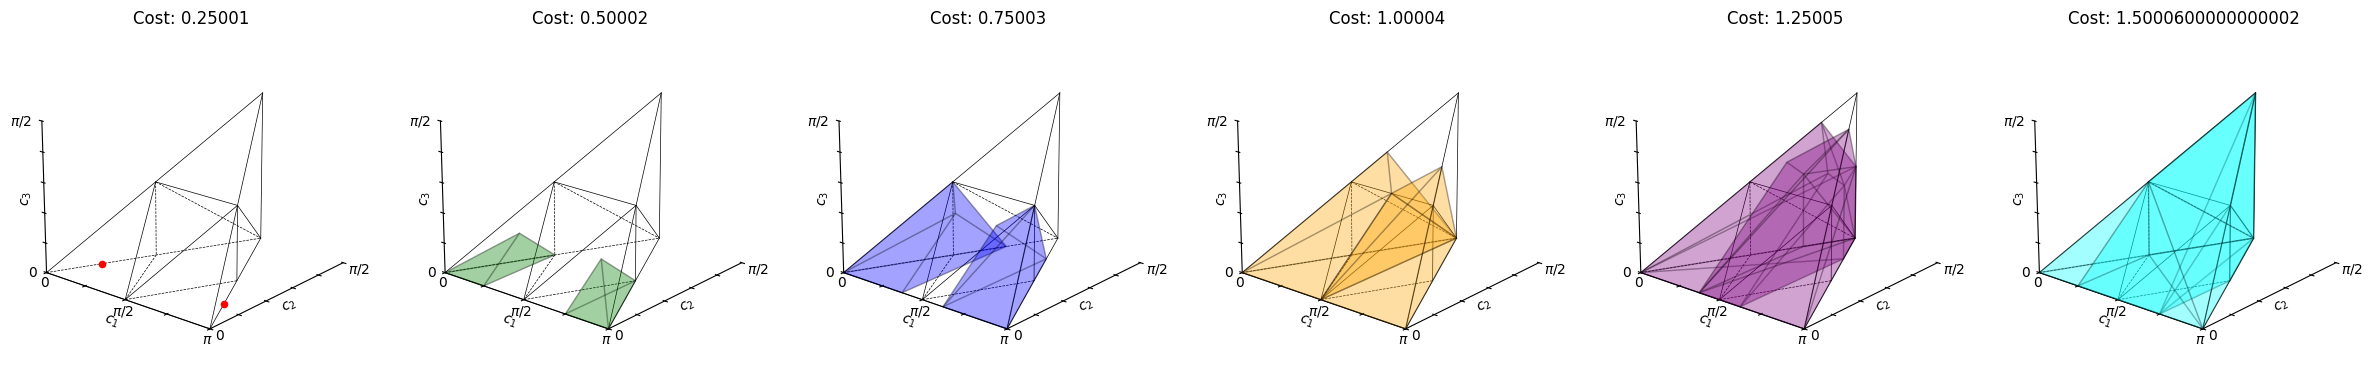

(np.float64(0.9599320617283754), np.float64(3.8395746639269444), np.float64(3.8395746639269444))


In [10]:
# NOTE if this coverage_set looks odd, it is likely due to setting COST_1Q >0
# this is a good idea for sorting equivalent cost sentences but prioritizing less total segments
# TODO reduce to isa coverage set to avoid this issue, prune more expensive + redundant circuit polytopes
# can use polytope.contains(polytope2) method?
# however, it will split up coverage_set into more pieces due to fine grained cost differences
if hasattr(decomposer.isa, "coverage_set"):
    _plot_coverage_set(decomposer.isa.coverage_set)
    print(expected_costs(decomposer.isa.coverage_set))

In [11]:
logger.setLevel("INFO")
N = 1_000

# Warm-start to trigger JIT compilation (optional)
_ = decomposer(random_unitary(4, seed=0))

fidelities = []
all_timings = []
failures = 0

for idx in trange(N, desc="Decomposing random unitaries"):
    u = random_unitary(4, seed=idx)
    try:
        v = Operator(decomposer(u))
        fid = average_gate_fidelity(u, v)

        if fid < 1 - 1e-8:
            raise ValueError(f"Fidelity too low: {fid:.8f}")

        fidelities.append(fid)
        all_timings.append(decomposer.last_timing)

    except Exception as e:
        print(f"[WARN] Failed on unitary {idx}: {e}")
        failures += 1

# === Fidelity Statistics ===
fidelities = np.array(fidelities)
print(f"\n✔ Completed {len(fidelities)} successful runs (out of {N})")
print(f"  → Failures: {failures}")
print(f"  → Median Fidelity: {np.median(fidelities)}")
print(f"  → Mean Fidelity:   {np.mean(fidelities)}")
print(f"  → Min Fidelity:    {np.min(fidelities)}")

# === Timing Statistics ===
if all_timings:
    phase_names = list(all_timings[0].keys())
    timing_array = np.array([[t[k] for k in phase_names] for t in all_timings])

    print("\nAverage phase durations:")
    for k, mean_time in zip(phase_names, timing_array.mean(axis=0)):
        print(f"  {k:>10}: {mean_time:.4f} s")

    print(f"\n  Total average time: {timing_array.sum(axis=1).mean():.4f} s")
else:
    print("No successful timings collected.")

Decomposing random unitaries:  42%|████▏     | 424/1000 [00:15<00:23, 25.03it/s]

[WARN] Failed on unitary 419: Segment 2 synthesis failed (residual norm=6.54e-09).


Decomposing random unitaries:  53%|█████▎    | 533/1000 [00:19<00:19, 23.52it/s]

[WARN] Failed on unitary 529: Segment 3 synthesis failed (residual norm=1.35e-07).


Decomposing random unitaries: 100%|██████████| 1000/1000 [00:35<00:00, 27.98it/s]


✔ Completed 998 successful runs (out of 1000)
  → Failures: 2
  → Median Fidelity: 0.9999999999999822
  → Mean Fidelity:   0.999999999996783
  → Min Fidelity:    0.9999999997146085

Average phase durations:
  lp_sentence: 0.0026 s
    segments: 0.0307 s

  Total average time: 0.0334 s


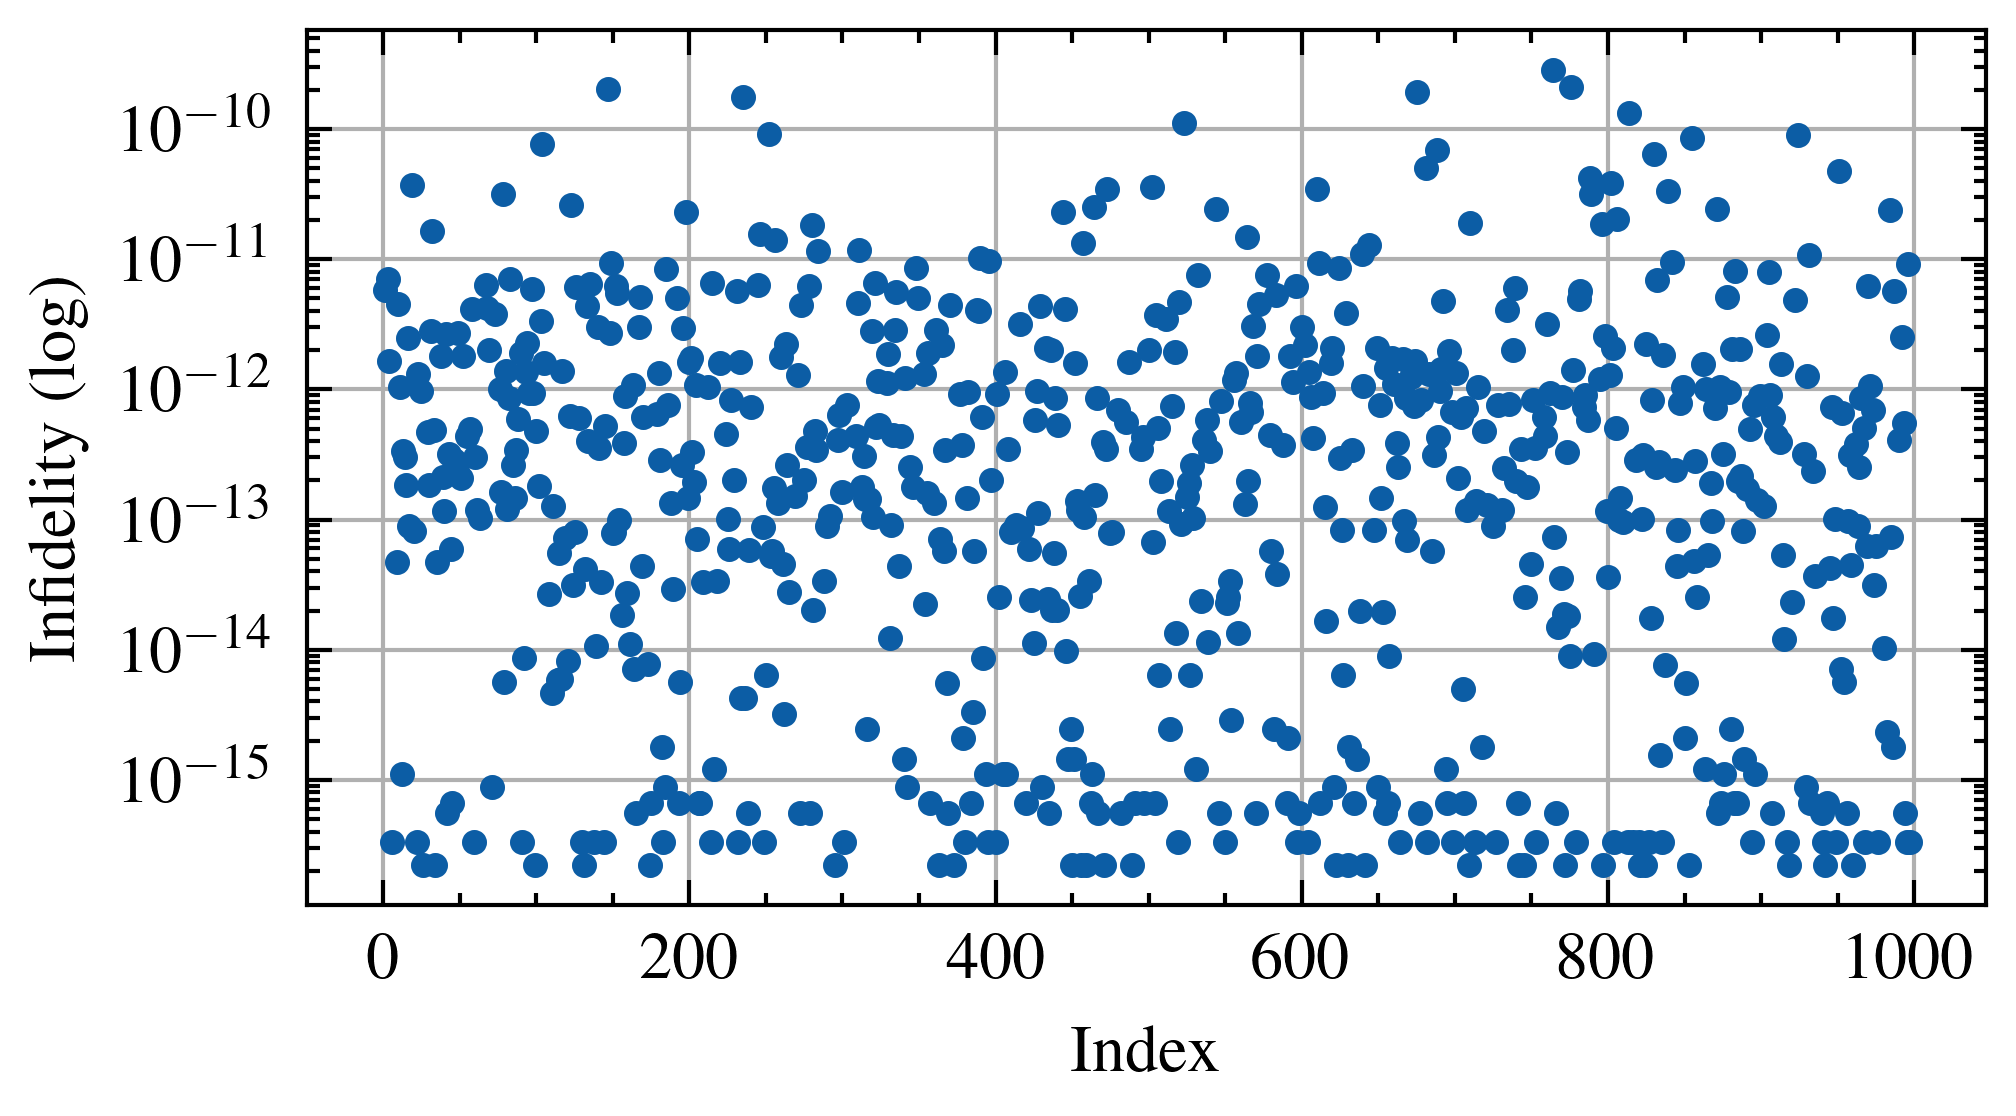

In [12]:
# make a plot for the fidelities
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, ax = plt.subplots(figsize=(3.5, 2))
    ax.plot(1 - fidelities, marker="o", markersize=2, linestyle="None")
    ax.set_xlabel("Index")
    ax.set_ylabel("Infidelity (log)")
    ax.set_yscale("log")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

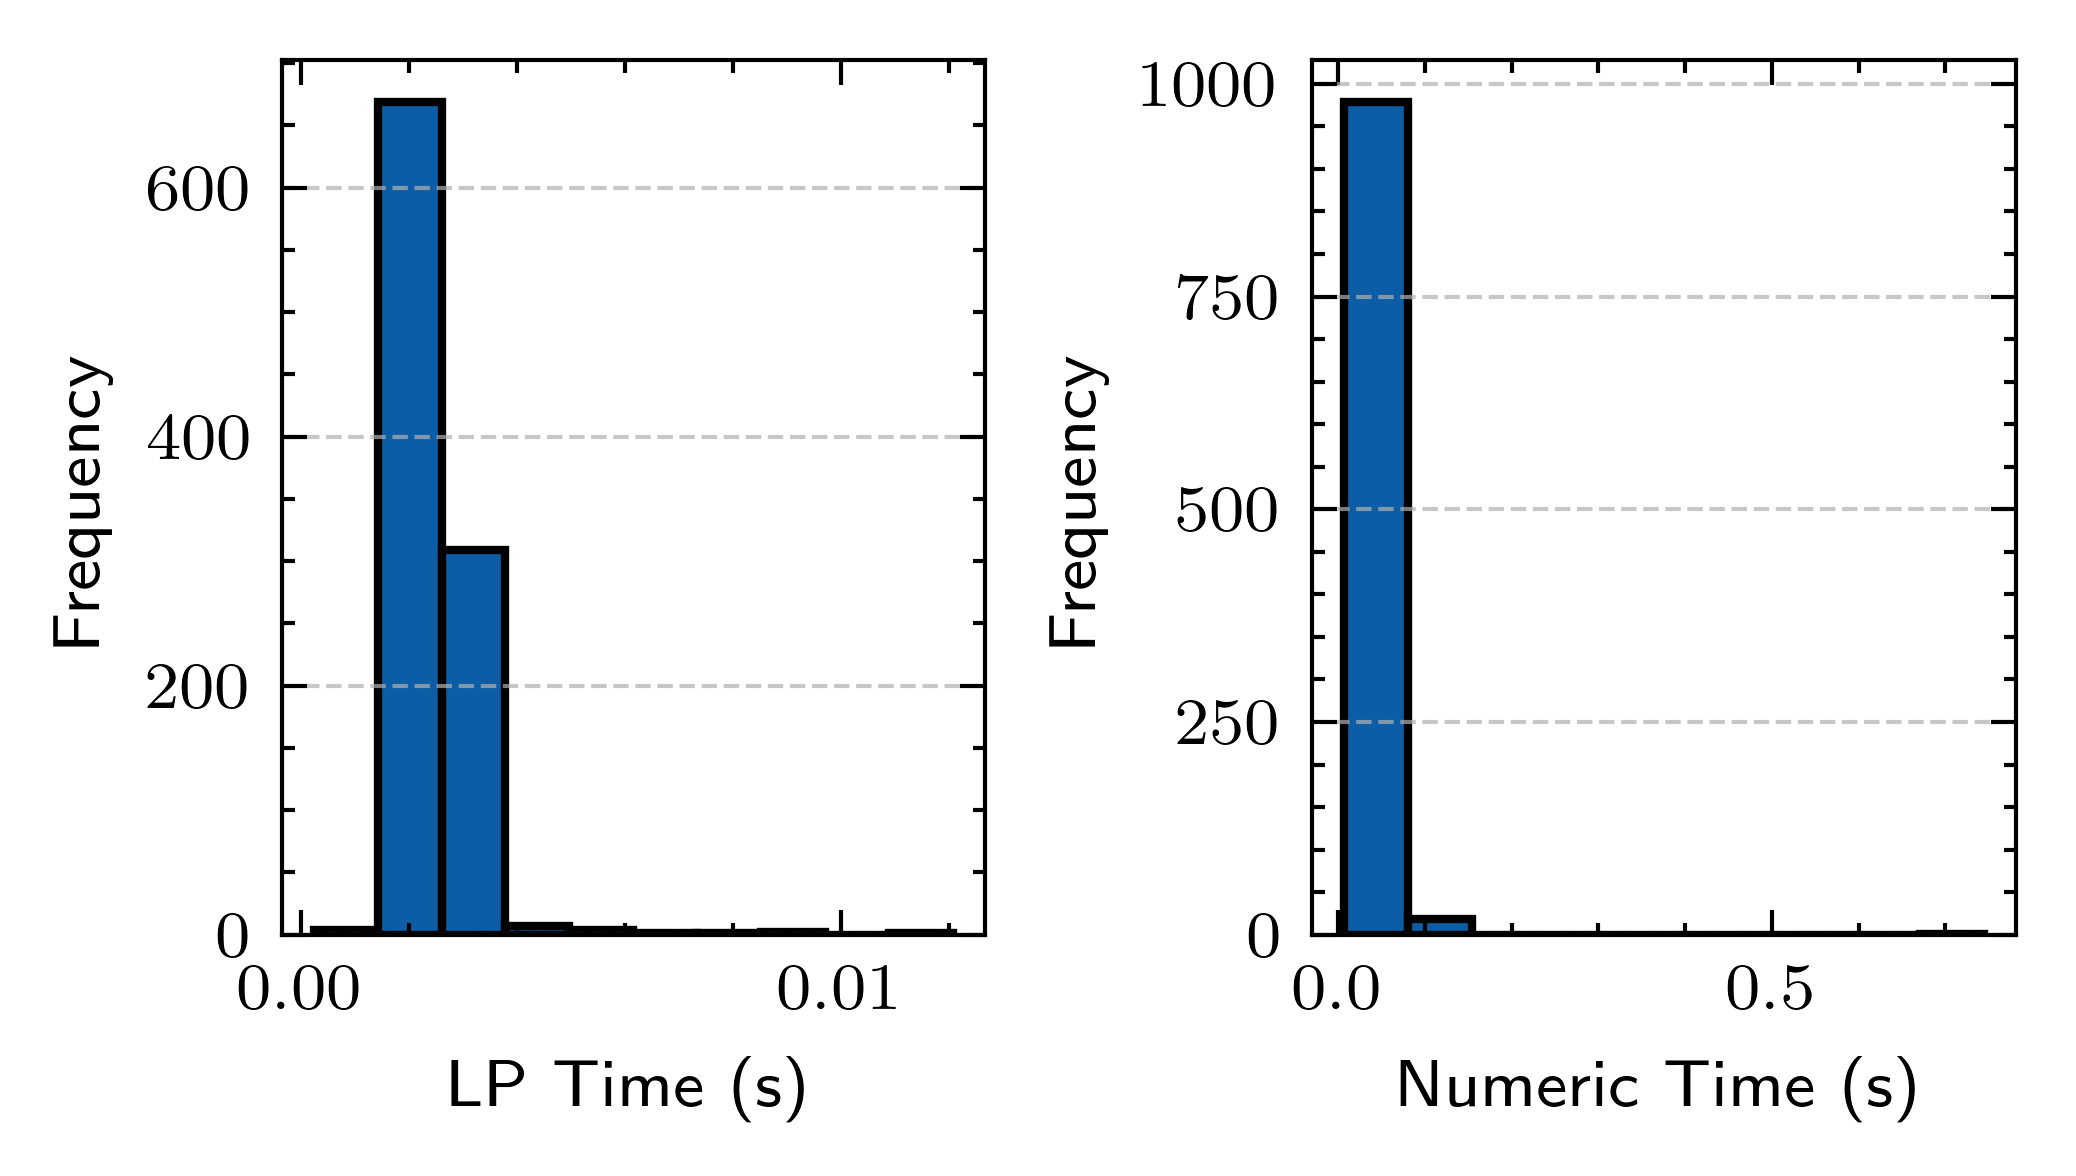

In [13]:
# Convert list of dicts to lists of values
lp_times = [d["lp_sentence"] for d in all_timings]
numeric_times = [d["segments"] for d in all_timings]

with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, 2, figsize=(3.5, 2))

    axes[0].set_xlabel("LP Time (s)")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(axis="y", linestyle="--", alpha=0.7)
    axes[0].hist(lp_times, edgecolor="black")

    axes[1].set_xlabel("Numeric Time (s)")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(axis="y", linestyle="--", alpha=0.7)
    axes[1].hist(numeric_times, edgecolor="black")

    fig.tight_layout()
plt.show()

#### Inspecting the pieces

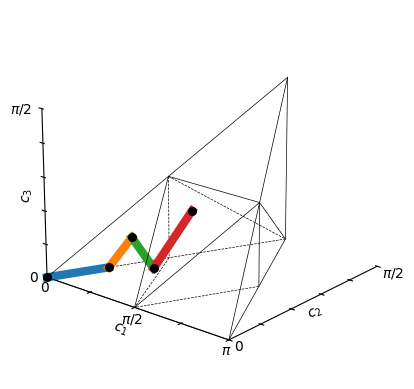

In [ ]:
example_input = random_unitary(4, seed=0)
example_sentence, example_intermediates = decomposer._best_decomposition(
    target_inv=GateInvariants.from_unitary(example_input, enforce_alcove=True)
)
render_path(example_intermediates);

In [ ]:
# NOTE, try with/out this reflection.
# the Decomposer has interal logic to handle this.
# example_intermediates = [x.rho_reflect for x in example_intermediates]

example_segment_solutions = decomposer._numerics._synthesize_segments(
    example_sentence, example_intermediates
)
print("Segment solutions:", example_segment_solutions)

# Recover unitary equivalence by promoting local equivalence
ret = decomposer._numerics._stitch_segments(
    example_sentence, example_intermediates, example_segment_solutions
)
U, V = c1c2c3(example_input), c1c2c3(Operator(ret).data)
print("Input unitary weyl invariants:", U)
print("Output unitary weyl invariants:", V)

ret.draw("mpl")

AttributeError: 'GulpsDecomposer' object has no attribute '_numerics'

### Usage as a TransformationPass 
This works but not ideally due to the hashing behavior. There are some work arounds for caching attributes for passes, see SolovayKitaev pass for example.

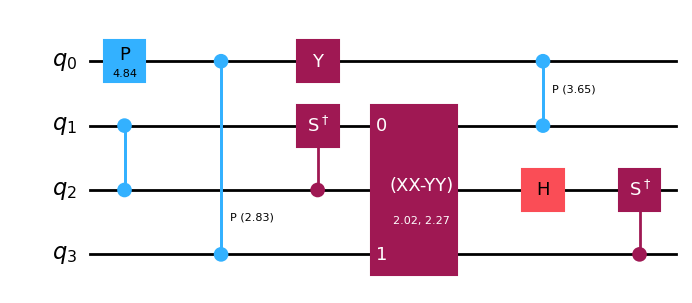

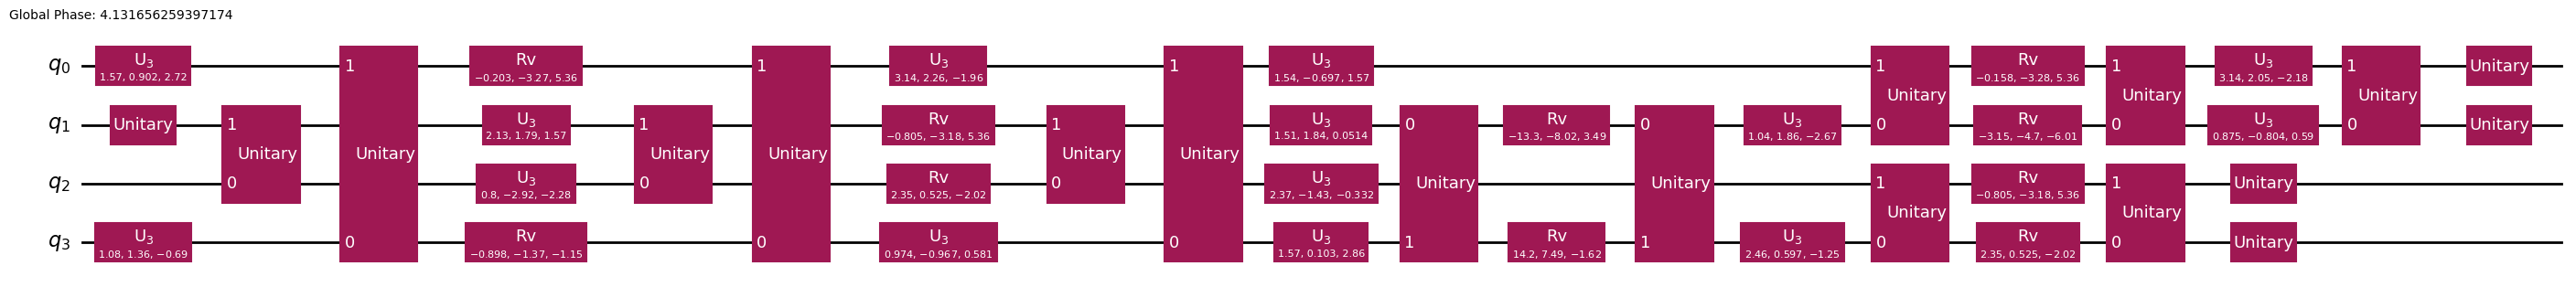

In [ ]:
input_qc = random_circuit(
    4, 4, max_operands=2, num_operand_distribution={1: 0.2, 2: 0.8}
)
display(input_qc.draw("mpl"))

# FIXME hashable?
hashable_gate_set = [x.to_matrix() for x in gate_set]
pm = PassManager(
    [
        GulpsDecompositionPass(hashable_gate_set, costs),
        Optimize1qGatesDecomposition(),
    ]
)
output_qc = pm.run(input_qc)
output_qc.draw("mpl", fold=-1)

### Usage as a Unitary Synthesis Plugin (Broken)

In [ ]:
# # check that the plugin is installed
# from qiskit.transpiler.passes.synthesis import unitary_synthesis_plugin_names

# unitary_synthesis_plugin_names()

In [ ]:
# # create some mock hetereogeneous ISA backend
# target = Target()

# target.add_instruction(
#     RZXGate(np.pi / 2),
#     {
#         (0, 1): InstructionProperties(
#             duration=100,
#             error=0.01,
#         )
#     },
#     name="cx",
# )
# target.add_instruction(
#     RZXGate(np.pi / 4),
#     {
#         (0, 1): InstructionProperties(
#             duration=50,
#             error=0.05,
#         )
#     },
#     name="scx",
# )

# target.add_instruction(
#     XXPlusYYGate(np.pi),
#     {
#         (0, 1): InstructionProperties(
#             duration=200,
#             error=0.02,
#         )
#     },
#     name="iswap",
# )
# target.add_instruction(
#     XXPlusYYGate(np.pi / 2),
#     {
#         (0, 1): InstructionProperties(
#             duration=100,
#             error=0.01,
#         )
#     },
#     name="siswap",
# )

# theta = Parameter("theta")
# phi = Parameter("phi")
# lam = Parameter("lambda")
# u_props = {
#     (0,): InstructionProperties(duration=0, error=0),
#     (1,): InstructionProperties(duration=0, error=0),
# }
# target.add_instruction(UGate(theta, phi, lam), u_props)

In [ ]:
# circuit = QuantumCircuit(2)
# # circuit.cx(0, 1)
# circuit.append(UnitaryGate(Operator(CXGate())), [0, 1])

# pass_manager = generate_preset_pass_manager(
#     optimization_level=3,
#     target=target,
#     translation_method="synthesis",
#     unitary_synthesis_method="gulps",
# )

# out = pass_manager.run(circuit)
# out.draw("mpl")